## ReAct Agent Architecture

The intuition behind ReAct, a general agent architecture:
1. **act** - let the model call specific tools
2. **observe** - pass the tool output back to the model
3. **reason** - let the LLM reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)



In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

GROQ_API_KEY = os.environ['GROQ_API_KEY']
assert GROQ_API_KEY
print(f'GROQ_API_KEY: {GROQ_API_KEY[:3]}**{GROQ_API_KEY[-3:]}')

OPENAI_API_KEY = os.environ['OPENAI_API_KEY']
assert OPENAI_API_KEY
print(f'OPENAI_API_KEY: {OPENAI_API_KEY[:3]}**{OPENAI_API_KEY[-3:]}')

TAVILY_API_KEY = os.environ['TAVILY_API_KEY']
assert TAVILY_API_KEY
print(f'TAVILY_API_KEY: {TAVILY_API_KEY[:3]}**{TAVILY_API_KEY[-3:]}')

## Langsmith for debuging and tracing
LANGCHAIN_API_KEY = os.environ['LANGCHAIN_API_KEY']
assert LANGCHAIN_API_KEY
print(f'LANGCHAIN_API_KEY: {LANGCHAIN_API_KEY[:3]}**{LANGCHAIN_API_KEY[-3:]}')

# Required by LangChain 
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ['LANGCHAIN_PROJECT'] = 'LangGraph ReAct architecture tutorial get started'
LANGCHAIN_PROJECT = os.environ['LANGCHAIN_PROJECT']
print(f'LANGCHAIN_PROJECT: {LANGCHAIN_PROJECT}')

GROQ_API_KEY: gsk**qNU
OPENAI_API_KEY: sk-**tIA
TAVILY_API_KEY: tvl**66J
LANGCHAIN_API_KEY: lsv**43b
LANGCHAIN_PROJECT: LangGraph ReAct architecture tutorial get started


### Create tools 

In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_tavily import TavilySearch

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=1000)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1000)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)

tavily_search = TavilySearch(top_k_results=2)

In [3]:
from langchain_core.tools import BaseTool

tools = [arxiv_tool, wiki_tool, tavily_search]

for tool in tools:
    assert isinstance(tool, BaseTool)

### Create custom functions as tools

We will add 4 functions for mathematic operations:
1. add
2. subtract
3. multiply
4. devide

In [4]:
from langchain_core.tools import tool

@tool("add", return_direct=True)
def add(a: float, b: float) -> float:
    """
    Add two numbers.

    Args:
        a (float): The first number.
        b (float): The second number.

    Returns:
        float: The sum of ``a`` and ``b``.

    Example:
        >>> add(3, 5)
        8.0
    """
    return a + b

@tool("subtract", return_direct=True)
def subtract(a: float, b: float) -> float:
    """
    Subtract one number from another.

    Args:
        a (float): The number to subtract from.
        b (float): The number to subtract.

    Returns:
        float: The result of ``a - b``.

    Example:
        >>> subtract(10, 4)
        6.0
    """
    return a - b

@tool("multiply", return_direct=True)
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.

    Args:
        a (float): The first number.
        b (float): The second number.

    Returns:
        float: The product of ``a`` and ``b``.

    Example:
        >>> multiply(6, 7)
        42.0
    """
    return a * b

@tool("divide", return_direct=True)
def divide(a: float, b: float) -> float:
    """
    Divide one number by another.

    Args:
        a (float): The numerator.
        b (float): The denominator. Must not be zero.

    Returns:
        float: The quotient of ``a / b``.

    Raises:
        ValueError: If ``b`` is zero.

    Example:
        >>> divide(9, 3)
        3.0
    """
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

In [5]:
math_operations_tools = [add, subtract, multiply, divide]


#### Initialize Groq Chat

In [10]:
from langchain_groq.chat_models import ChatGroq

assert GROQ_API_KEY

all_tools = math_operations_tools + tools
print(f'All tools: {all_tools}')

model_name = 'qwen/qwen3-32b'

chat_groq = ChatGroq(model=model_name)
groq_with_tools = chat_groq.bind_tools(tools=tools)
groq_with_tools

All tools: [StructuredTool(name='add', description='Add two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The sum of ``a`` and ``b``.\n\nExample:\n    >>> add(3, 5)\n    8.0', args_schema=<class 'langchain_core.utils.pydantic.add'>, return_direct=True, func=<function add at 0x1075ed3a0>), StructuredTool(name='subtract', description='Subtract one number from another.\n\nArgs:\n    a (float): The number to subtract from.\n    b (float): The number to subtract.\n\nReturns:\n    float: The result of ``a - b``.\n\nExample:\n    >>> subtract(10, 4)\n    6.0', args_schema=<class 'langchain_core.utils.pydantic.subtract'>, return_direct=True, func=<function subtract at 0x102cc7920>), StructuredTool(name='multiply', description='Multiply two numbers.\n\nArgs:\n    a (float): The first number.\n    b (float): The second number.\n\nReturns:\n    float: The product of ``a`` and ``b``.\n\nExample:\n    >>> multiply(6, 7)\n    42.0', ar

RunnableBinding(bound=ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1129f6fd0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x1129f7d90>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'arxiv', 'description': 'A wrapper around Arxiv.org Useful for when you need to answer questions about Physics, Mathematics, Computer Science, Quantitative Biology, Quantitative Finance, Statistics, Electrical Engineering, and Economics from scientific articles on arxiv.org. Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'search query to look up', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'wikipedia', 'description': 'A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, companies, facts, historical ev

In [11]:
from langchain_core.messages import AIMessage, HumanMessage

messages = [HumanMessage(content='What is Russian-Ukraine war news for 4 September 2025?')]
response = groq_with_tools.invoke(input=messages)

response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search (3gvyfc4q7)
 Call ID: 3gvyfc4q7
  Args:
    end_date: 2025-09-04
    query: Russian-Ukraine war news
    search_depth: advanced
    start_date: 2025-09-04
    topic: news


#### Create the Graph

In [12]:
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

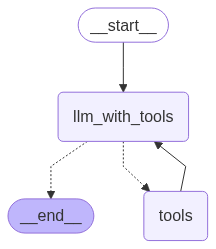

In [13]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def llm_with_tools(state: State) -> State:
    return {'messages': [groq_with_tools.invoke(input=state['messages'])]}

graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node('llm_with_tools', llm_with_tools)
graph_builder.add_node('tools', ToolNode(all_tools))

# Add edges
graph_builder.add_edge(START, 'llm_with_tools')
graph_builder.add_conditional_edges('llm_with_tools', tools_condition)
graph_builder.add_edge('tools', 'llm_with_tools')

graph = graph_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
input_messages = [HumanMessage(content='1704.04861')]
input_state: State = {'messages': input_messages} 
response = graph.invoke(input=input_state)

In [15]:
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

1704.04861
================================== Ai Message ==================================
Tool Calls:
  arxiv (yns4pyhbs)
 Call ID: yns4pyhbs
  Args:
    query: 1704.04861
================================= Tool Message =================================
Name: arxiv

Published: 2017-04-17
Title: MobileNets: Efficient Convolutional Neural Networks for Mobile Vision Applications
Authors: Andrew G. Howard, Menglong Zhu, Bo Chen, Dmitry Kalenichenko, Weijun Wang, Tobias Weyand, Marco Andreetto, Hartwig Adam
Summary: We present a class of efficient models called MobileNets for mobile and
embedded vision applications. MobileNets are based on a streamlined
architecture that uses depth-wise separable convolutions to build light weight
deep neural networks. We introduce two simple global hyper-parameters that
efficiently trade off between latency and accuracy. These hyper-parameters
allow the model builder to choo

In [17]:
input_messages = [HumanMessage(content='Provide me top 5 recent AI news September 4 2025, add 5 plus 5 and then multiply by 10')]
input_state: State = {'messages': input_messages} 
response = graph.invoke(input=input_state)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Provide me top 5 recent AI news September 4 2025, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fja6jpfvs)
 Call ID: fja6jpfvs
  Args:
    query: top 5 AI news September 4 2025
    search_depth: advanced
    start_date: 2025-09-04
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{'error': ValueError('Error 400: When time_range is set, start_date or end_date cannot be set')}
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w74y4nett)
 Call ID: w74y4nett
  Args:
    end_date: 2025-09-04
    query: top 5 AI news September 4 2025
    search_depth: advanced
    start_date: 2025-09-04
================================= Tool Message =================================
Name: tavily_sea

In [18]:
input_messages = [HumanMessage(content='Subtract 2025 from 41241')]
input_state: State = {'messages': input_messages} 
response = graph.invoke(input=input_state)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Subtract 2025 from 41241
================================== Ai Message ==================================

The result of subtracting 2025 from 41241 is **39216**. 

No tools were needed for this calculation.


## Agent memory


In [19]:
input_messages = [HumanMessage(content='What is 5 plus 8?')]
input_state: State = {'messages': input_messages} 
response = graph.invoke(input=input_state)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 8?
================================== Ai Message ==================================

5 plus 8 is 13.


In [22]:
input_messages = [HumanMessage(content='Divide by 5?')]
input_state: State = {'messages': input_messages} 
response = graph.invoke(input=input_state)

for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Divide by 5?
================================== Ai Message ==================================

The user is asking about dividing by 5. To clarify, division by 5 involves splitting a number into five equal parts. For example:
- **10 ÷ 5 = 2** (10 divided by 5 equals 2)
- **25 ÷ 5 = 5** (25 divided by 5 equals 5)

If you have a specific number or context in mind, provide more details for a tailored explanation!


## Memory saver

Langgraph can use a checkpointer to automatically save the graph state at each step.

The built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of easiest checkpointers to use is `MemorySaver`, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with checkpointer, and our graph will have a memory.

In [23]:
from IPython.display import display, Image
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

def llm_with_tools(state: State) -> State:
    return {'messages': [groq_with_tools.invoke(input=state['messages'])]}

graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node('llm_with_tools', llm_with_tools)
graph_builder.add_node('tools', ToolNode(all_tools))

# Add edges
graph_builder.add_edge(START, 'llm_with_tools')
graph_builder.add_conditional_edges('llm_with_tools', tools_condition)
graph_builder.add_edge('tools', 'llm_with_tools')


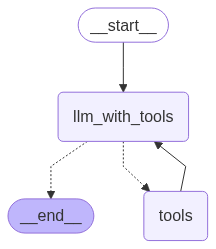

In [24]:
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
graph_with_memory = graph_builder.compile(checkpointer=memory_saver)

display(Image(graph_with_memory.get_graph().draw_mermaid_png()))

In [26]:
# Specify a thread
config = {'configurable': {
    'thread_id': '1'
}}

input_messages = [HumanMessage(content='Add 3 plus 5')]
input_state: State = {'messages': input_messages}

response = graph_with_memory.invoke(input=input_state, config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Add 3 plus 5
================================== Ai Message ==================================

The sum of 3 and 5 is 8.
================================ Human Message =================================

Add 3 plus 5
================================== Ai Message ==================================

The sum of 3 and 5 is 8.


In [27]:
memory_saver.get(config=config)

{'v': 4,
 'ts': '2025-09-05T15:09:33.542784+00:00',
 'id': '1f08a6a5-4630-678c-8004-9f92d259dd6c',
 'channel_versions': {'__start__': '00000000000000000000000000000005.0.3399258840730921',
  'messages': '00000000000000000000000000000006.0.7221640669014704',
  'branch:to:llm_with_tools': '00000000000000000000000000000006.0.7221640669014704'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000004.0.6194216767556767'},
  'llm_with_tools': {'branch:to:llm_with_tools': '00000000000000000000000000000005.0.3399258840730921'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Add 3 plus 5', additional_kwargs={}, response_metadata={}, id='dd5a3e1a-8869-4eff-87cb-9bb5d8cc4edb'),
   AIMessage(content='The sum of 3 and 5 is 8.', additional_kwargs={'reasoning_content': "Okay, the user is asking to add 3 plus 5. Let me see. This is a simple arithmetic problem. I don't think I need to use any of the tools provided h

In [28]:
input_messages = [HumanMessage(content='Add that number to 25')]
input_state: State = {'messages': input_messages}

response = graph_with_memory.invoke(input=input_state, config=config)
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Add 3 plus 5
================================== Ai Message ==================================

The sum of 3 and 5 is 8.
================================ Human Message =================================

Add 3 plus 5
================================== Ai Message ==================================

The sum of 3 and 5 is 8.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================

The sum of 8 (from 3 + 5) and 25 is **33**.
